# データの前処理

In [1]:
from torchvision.datasets import CIFAR10
from torchvision.datasets import CIFAR100
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 回転とリサイズ
affine = transforms.RandomAffine([-30, 30], scale=(0.8, 1.2))
# シフト
shift = transforms.RandomAffine((0, 0), translate=(0.5, 0.5))
# 左右反転
flip = transforms.RandomHorizontalFlip(p=0.5)
# 一部を消去
erasing = transforms.RandomErasing(p=0.5)
# 平均値を0, 標準偏差を1にする
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))
to_tensor = transforms.ToTensor()

# ノイズなしの訓練データ
transform_train = transforms.Compose([to_tensor, normalize])
# 一部消去した訓練データ
transform_train_erasing = transforms.Compose([to_tensor, erasing, normalize])
# 複数のノイズをランダムで与えた訓練データ
transform_train_random = transforms.Compose([
    transforms.RandomApply([affine], p=0.5),
    transforms.RandomApply([shift], p=0.5),
    transforms.RandomApply([flip], p=0.5),
    to_tensor,
    transforms.RandomApply([erasing], p=0.5),
    normalize,
])

transform_test = transforms.Compose([to_tensor, normalize])
cifar10_train = CIFAR10("./data", train=True, download=True, transform=transform_train)
cifar10_train_erasing = CIFAR10("./data", train=True, download=True, transform=transform_train_erasing)
cifar10_train_random = CIFAR10("./data", train=True, download=True, transform=transform_train_random)
cifar10_test = CIFAR10("./data", train=False, download=True, transform=transform_test)

# cifar100データセット
cifar100_train = CIFAR100("./data", train=True, download=True, transform=transform_train)
cifar100_train_random = CIFAR100("./data", train=True, download=True, transform=transform_train_random)
cifar100_test = CIFAR100("./data", train=False, download=True, transform=transform_test)

# DataLoaderの設定
batch_size = 64
train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
train_loader_erasing = DataLoader(cifar10_train_erasing, batch_size=batch_size, shuffle=True)
train_loader_random = DataLoader(cifar10_train_random, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

train_loader_100 = DataLoader(cifar100_train, batch_size=batch_size, shuffle=True)
train_loader_random_100 = DataLoader(cifar100_train_random, batch_size=batch_size, shuffle=True)
test_loader_100 = DataLoader(cifar100_test, batch_size=batch_size, shuffle=False)

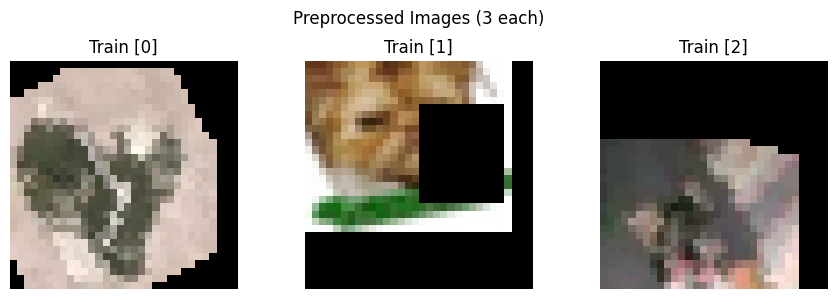

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for i in range(3):
    img = next(iter(train_loader_random))[0][i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[i].imshow(img)
    axes[i].set_title(f"Train [{i}]")
    axes[i].axis('off')

plt.suptitle("Preprocessed Images (3 each)")
plt.tight_layout()
plt.show()


## グラフ描画関数と学習率計算関数を定義

In [3]:
import matplotlib.pyplot as plt
import torch
from pathlib import Path

def plot_loss_curve(record_loss_train, record_loss_test):
    plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
    plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.show()

def load_training_results(model_class, checkpoint_path, device="cuda"):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"保存済みの学習結果がありません: {checkpoint_path}. 先に学習セルを1回だけ実行してください。"
        )

    checkpoint = torch.load(checkpoint_path, map_location=device)
    net = model_class().to(device)
    net.load_state_dict(checkpoint["model_state_dict"])

    return net, checkpoint["record_loss_train"], checkpoint["record_loss_test"]

def calculate_accuracy(net, data_loader, device="cuda", num_classes=10):
    # macro平均のprecision / recallを計算する
    tp_per_class = torch.zeros(num_classes, dtype=torch.long)
    fp_per_class = torch.zeros(num_classes, dtype=torch.long)
    fn_per_class = torch.zeros(num_classes, dtype=torch.long)

    correct = 0
    total = 0

    net.eval()
    with torch.no_grad():
        for _, (x, t) in enumerate(data_loader):
            x, t = x.to(device), t.to(device)
            y = net(x)
            pred = y.argmax(1)

            correct += (pred == t).sum().item()
            total += len(x)

            for c in range(num_classes):
                tp_per_class[c] += ((pred == c) & (t == c)).sum().cpu()
                fp_per_class[c] += ((pred == c) & (t != c)).sum().cpu()
                fn_per_class[c] += ((pred != c) & (t == c)).sum().cpu()

    accuracy = correct / total
    precision_per_class = tp_per_class.float() / (tp_per_class.float() + fp_per_class.float() + 1e-12)
    recall_per_class = tp_per_class.float() / (tp_per_class.float() + fn_per_class.float() + 1e-12)

    precision = precision_per_class.mean().item()
    recall = recall_per_class.mean().item()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
    }



# テスト用に1エポック学習して保存する
- データ：複数ノイズをランダム付与した訓練データ
- モデル：Net2（Conv: 3→32→64, カーネル3x3, FC: 64x6x6→256→10）
- エポック数：1
- 保存先：Google Drive のテスト用チェックポイント

In [4]:
import torch.nn as nn

class Net2(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 32, 3)     # フィルタ数6->32、フィルタサイズ5->3
        self.conv2 = nn.Conv2d(32, 64, 3)        # フィルタ数16->64、フィルタサイズを5->3

        # 活性化関数ReLU
        self.relu = nn.ReLU()

        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)
        
        # 全結合層
        self.fc1 = nn.Linear(64*6*6, 256)

        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)

        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
# Google Drive マウント
from google.colab import drive
try:
    print("mount start")
    drive.mount("/content/drive")
    print("mount finished")
except Exception as e:
    raise RuntimeError(
        "Google Drive のマウントに失敗しました。ブラウザ側の Colab で Drive をマウントしてから再実行してください。"
    ) from e

# net初期化
net = Net2()
net.cuda() # GPU対応

from pathlib import Path
from torch import optim

# 保存先
checkpoint_path = Path("/content/drive/MyDrive/AI_model_learning/net2_cifar10_random_epoch200.pt")
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(200): # 200エポック学習
    print(i, ": start")
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_random): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

torch.save({
    "model_state_dict": net.state_dict(),
    "record_loss_train": record_loss_train,
    "record_loss_test": record_loss_test,
}, checkpoint_path)
print(f"Saved: {checkpoint_path}")

mount start
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
mount finished
0 : start
Epoch: 0 Loss_Train: 1.9174188800784937 Loss_Test: 1.4917599327245337
1 : start
Epoch: 1 Loss_Train: 1.7184231540431147 Loss_Test: 1.3792274962564943
2 : start
Epoch: 2 Loss_Train: 1.6380804232929065 Loss_Test: 1.2698246172279308
3 : start
Epoch: 3 Loss_Train: 1.5917396924989609 Loss_Test: 1.2609313046856292
4 : start
Epoch: 4 Loss_Train: 1.551968886876655 Loss_Test: 1.191509265049248
5 : start
Epoch: 5 Loss_Train: 1.5108884469322537 Loss_Test: 1.1315083313899434
6 : start
Epoch: 6 Loss_Train: 1.4844294824563633 Loss_Test: 1.1014233007552519
7 : start
Epoch: 7 Loss_Train: 1.4614573715592893 Loss_Test: 1.067442274397346
8 : start
Epoch: 8 Loss_Train: 1.4423871054063977 Loss_Test: 1.045402190867503
9 : start
Epoch: 9 Loss_Train: 1.424238985761657 Loss_Test: 1.021990604081731
10 : start
Epoch: 10 Loss_Train: 1.413332382278979

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using checkpoint: /content/drive/MyDrive/AI_model_learning/net2_cifar10_random_epoch1_test.pt


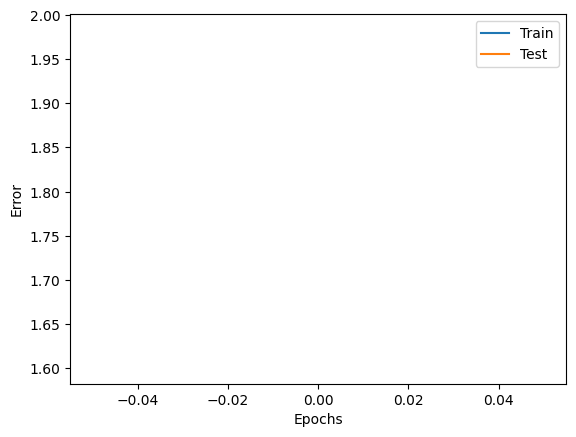

accuracy : 0.4215
precision: 0.4148
recall   : 0.4215


In [ ]:
# Google Drive マウント
from google.colab import drive
try:
    drive.mount("/content/drive")
except Exception as e:
    raise RuntimeError(
        "Google Drive のマウントに失敗しました。ブラウザ側の Colab で Drive をマウントしてから再実行してください。"
    ) from e

checkpoint_path = "/content/drive/MyDrive/AI_model_learning/net2_cifar10_random_epoch200.pt"
print(f"Using checkpoint: {checkpoint_path}")

net, record_loss_train, record_loss_test = load_training_results(
    Net2, checkpoint_path, device="cuda"
 )

# 結果出力
plot_loss_curve(record_loss_train, record_loss_test)
metrics = calculate_accuracy(net, test_loader, num_classes=10)
print(f"accuracy : {metrics['accuracy']:.4f}")
print(f"precision: {metrics['precision']:.4f}")
print(f"recall   : {metrics['recall']:.4f}")